Import 

In [1]:
import pandas as pd
import yaml
import sys
import matplotlib.pyplot as plt
import seaborn as sns 
import networkx as nx
import numpy as np
from plots_11 import hmap_red
from matplotlib.colors import ListedColormap

app_name = "mummi5node"
cp_dir = "/p/lustre2/pandey2/cp_dir/mummi/mummi5node"

with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    dlp_yaml = yaml.safe_load(file)
    app_root = dlp_yaml["app"]
sys.path.insert(0, app_root)

import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 
from dfanalyzer.plots import GrepIOPlots


/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


In [2]:
events_obj = DFGrepInterference(app_name=app_name,  cp_dir = cp_dir, existing=True)
inter = events_obj.inter.compute()
inter_data = inter[inter["size"] > 0]
inter_metadata = events_obj.inter_metadata.compute()

# Relationship 1: Events that interfer with each other
- **Question**: Can we identify I/O events which suffer from most I/O interferences?

- **Technique**: To do so, we calculate Interference Factor; which is the cost of I/O event by cost of an isolated I/O event. Then, we use this metric to identify the ideal parallelism fo a storage target by observing the Interferance factor per transfer size.

- **Graph**: (Overlap Graph)
    - *Vertex*: I/O events
    - *Edges*: Time overlap between the requests
    - *Graph Type*: Undirected
    - *Metric*: Interference Factor 

In [3]:
# Labels
size_bins = [
0, 512, 1024, 2048, 4096, 8192, 16384, 32768, 65536, 131072, 262144, 524288,
1048576, 2097152, 4194304, 8388608, 16777216, 33554432, 67108864, 134217728,
268435456, 536870912, 1073741824, float('inf')
]
size_labels = [
'<512B', '512B-1KB', '1-2KB', '2-4KB', '4-8KB', '8-16KB', '16-32KB', '32-64KB',
'64-128KB', '128-256KB', '256-512KB', '512KB-1MB', '1-2MB', '2-4MB', '4-8MB',
'8-16MB', '16-32MB', '32-64MB', '64-128MB', '128-256MB', '256-512MB', '512MB-1GB', '>1GB'
]

degree_bins = [0,2,4,8,16,32,64,float('inf')]
degree_labels = ['<2','2-4','4-8','8-16', '16-32', '32-64','>64']


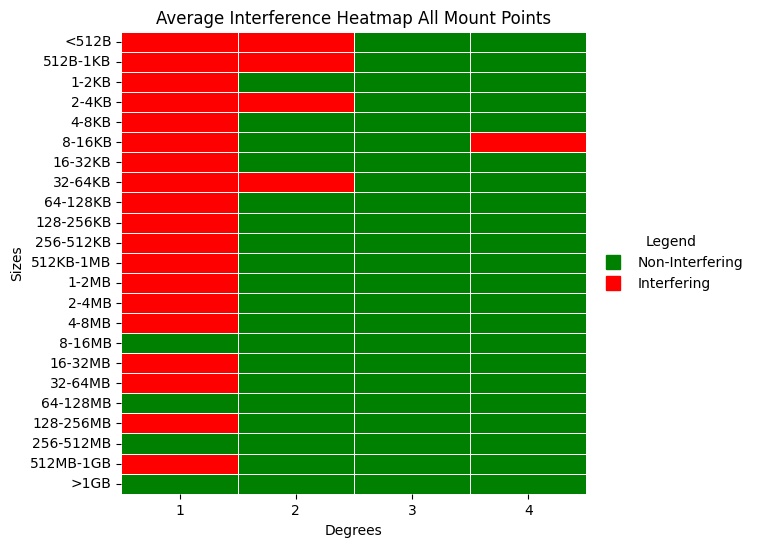

In [4]:
hmap_red(df=inter_data, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)

In [6]:
inter_data.mount_point.unique()

<ArrowStringArray>
['/p/gpfs1', '/p/vast1', '/tmp']
Length: 3, dtype: string

In [46]:
inter_data.query(f'mount_point == "/p/vast1"')

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,size_category,IF_val
6360,read,76673,1048576,16440983,16445735,/p/vast1,4752,0,1,1,44,1,1-2MB,0.009259
6361,read,76673,22,16457382,16457389,/p/vast1,7,0,1,1,7,0,<512B,1.000000
6362,read,76673,42,16463307,16463314,/p/vast1,7,0,1,1,7,0,<512B,1.000000
6363,read,76673,142,16467356,16467363,/p/vast1,7,0,1,1,7,0,<512B,1.000000
6364,read,76673,6270,16476415,16476423,/p/vast1,8,0,1,1,7,1,4-8KB,0.875000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6081,read,76673,1048576,5331563677,5331563746,/p/vast1,69,177,1,1,44,1,1-2MB,0.637681
6082,read,76673,22,5331590484,5331590492,/p/vast1,8,177,1,1,7,1,<512B,0.875000
6083,read,76673,42,5331604019,5331604026,/p/vast1,7,177,1,1,7,0,<512B,1.000000
6084,read,76673,250,5331612974,5331612981,/p/vast1,7,177,1,1,7,0,<512B,1.000000


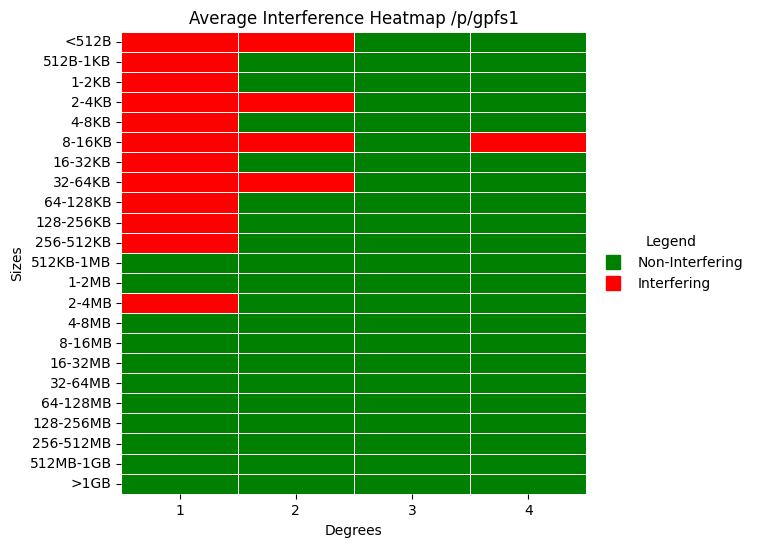

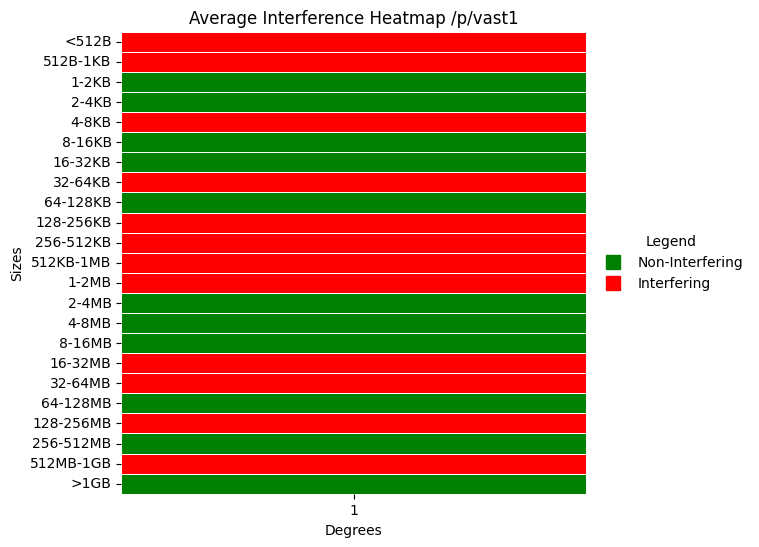

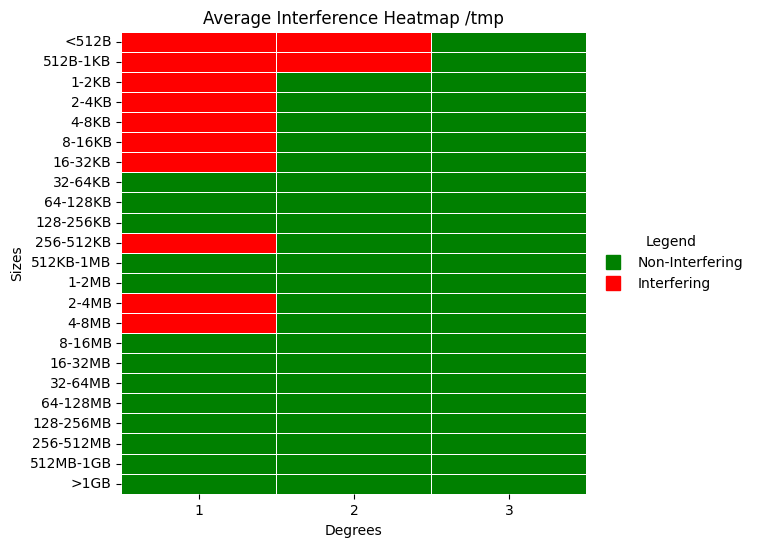

In [10]:
hmap_red(mp="/p/gpfs1", df=inter_data, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap_red(mp="/p/vast1", df=inter_data, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)
hmap_red(mp="/tmp", df=inter_data, size_bins=size_bins,
          size_labels=size_labels, degree_bins=degree_bins, degree_labels=degree_labels)


In [11]:
inter_data

,name,pid,size,ts,te,mount_point,dur,trange,deg_caller,deg_other,min_dur,interference,size_category,IF_val
0,write,76673,33854,90070695,90070781,/p/gpfs1,86,3,1,1,74,0.860465,32-64KB,0.860465
1,read,76673,4520,90419772,90419788,/p/gpfs1,16,3,1,1,16,1.0,4-8KB,1.000000
2,write,76673,33854,90596332,90596488,/p/gpfs1,156,3,1,1,74,0.474359,32-64KB,0.474359
3,read,76673,4671,90958443,90958458,/p/gpfs1,15,3,1,1,14,0.933333,4-8KB,0.933333
4,write,76673,33854,91171109,91171273,/p/gpfs1,164,3,1,1,74,0.45122,32-64KB,0.451220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182937,write,174828,635,6568953974,6568954013,/tmp,39,218,1,1,11,0.282051,512B-1KB,0.282051
182938,write,62692,227,6569616656,6569616693,/tmp,37,218,1,1,10,0.27027,<512B,0.270270
182939,write,62692,227,6569620351,6569620365,/tmp,14,218,1,1,10,0.714286,<512B,0.714286
182940,write,108460,228,6569641641,6569641711,/tmp,70,218,1,1,10,0.142857,<512B,0.142857


In [17]:
inter_data["interference"] = (1 / inter_data["IF_val"] > inter_data["deg_caller"]).astype(int)

In [39]:
inter_data.query('interference > 0 and deg_caller > 1').groupby(['mount_point','name','deg_caller'])['pid'].count()

mount_point  name   deg_caller
/p/gpfs1     read   2               5
                    4               1
             write  2               7
/tmp         read   2             400
             write  2             565
                    3               1
Name: pid, dtype: int64[pyarrow]

In [27]:
inter_metadata["interference"] = (1 / inter_metadata["IF_val"] > inter_metadata["deg_caller"]).astype(int)

In [29]:
inter_metadata.query('interference > 0 and deg_caller > 1').groupby(['mount_point','name'])['pid'].count()

mount_point  name      
/p/gpfs1     __fxstat64      3
             __lxstat64      3
             __xstat64       4
             chdir           3
             close          27
             lseek64        27
             mkdir           3
             open64         35
             readlink       33
             rename          1
/tmp         __fxstat64      2
             __xstat64      83
             lseek64         2
             mmap64         59
             open64          2
             readlink      328
Name: pid, dtype: int64[pyarrow]

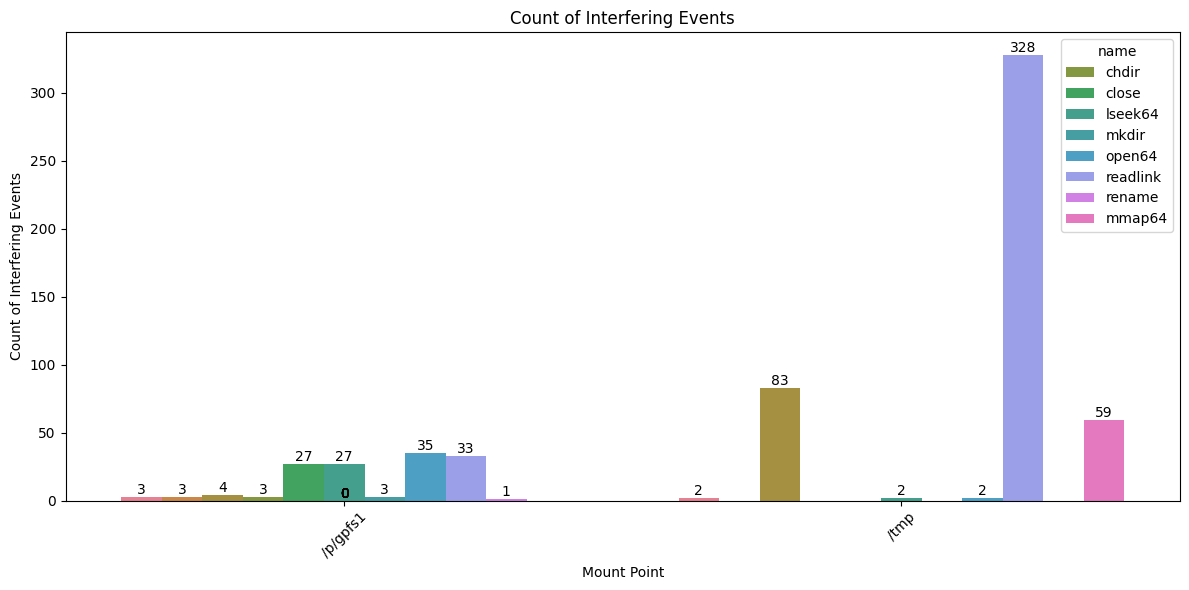

In [ ]:
# Assuming inter_metadata is your DataFrame
# Execute the query and group by 'mount_point' and 'name', then count the occurrences of 'pid'
grouped_data = inter_metadata.query('interference > 0 and deg_caller > 1').groupby(['mount_point', 'name'])['pid'].count().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=grouped_data, x='mount_point', y='pid', hue='name', dodge=True)

# Adding labels and title
plt.title('Count of Interfering Events')
plt.xlabel('Mount Point')
plt.ylabel('Count of Interfering Events')

# Annotate each bar with its value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



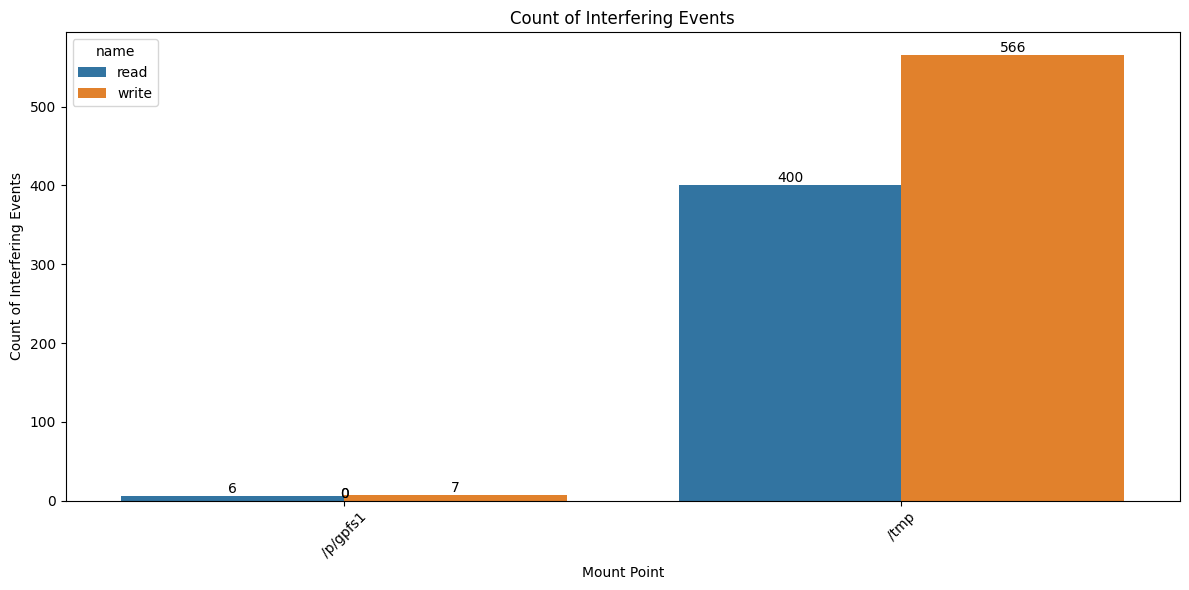

In [47]:
# Assuming inter_metadata is your DataFrame
# Execute the query and group by 'mount_point' and 'name', then count the occurrences of 'pid'
grouped_data = inter_data.query('interference > 0 and deg_caller > 1').groupby(['mount_point', 'name'])['pid'].count().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=grouped_data, x='mount_point', y='pid', hue='name', dodge=True)

# Adding labels and title
plt.title('Count of Interfering Events')
plt.xlabel('Mount Point')
plt.ylabel('Count of Interfering Events')

# Annotate each bar with its value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=10, color='black', 
                xytext=(0, 5), textcoords='offset points')

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()